### KLUE : korean language understanding evaluation(한국어 언어 이해 평가)
- 한국어 자연어 처리(NLP) 성능을 평가할 수 있는 '공식적 기준'(Benchmark set)을 만들기 위해 시작된 프로젝트
  - 영어는 이미 벤치마크로 GLUE, SuperGLUE 등이 존재
- 단순히 모델만 만든 것이 아닌, 다양한 평가 테크스, 데이터셋, 모델, 랭킹 시스템 등 포함한 종합적 시스템
- 각종 한국어 모델(KOBERT, KOELECTRA 등)의 성능 비교 평가의 기준 제공

---

### KLUE RoBERTa
- KLUE-RoBERTa는 한국어 자연어처리를 위해 학습된 RoBERTa(Robustly Optimized BERT Pretraining Approach) 구조 기반의 한국어 사전학습 언어모델이다.
  
  
- model : https://huggingface.co/klue/roberta-base
- github : https://github.com/KLUE-benchmark/KLUE

KLUE 벤치마크는 8가지 작업으로 구성됩니다.

- 주제 분류(TC)
- 문장 텍스트 유사성(STS)
- 자연어 추론(NLI)
- 명명된 엔터티 인식(NER)
- 관계 추출(RE)
- (품사) + 종속성 분석(DP)
- 기계 독해 이해(MRC)
- 대화 상태 추적(DST)

### dataset

In [ ]:
from google.colab import files
files.upload()

Saving test.csv to test.csv
Saving final.csv to final.csv


{'test.csv': b'id,is_offender,text\r\n2feb1ab709cc4a90890a5bad8a22f422,TRUE,\xbe\xc8\xb3\xe7 \xbc\xbd\xbd\xc3\r\n2feb1ab709cc4a90890a5bad8a22f422,FALSE,"\xbe\xee\xc0\xcc, \xbe\xc8\xb3\xe7!"\r\n2feb1ab709cc4a90890a5bad8a22f422,FALSE,\xc7\xd2 \xb8\xbb \xc0\xd6\xbe\xee.\r\n2feb1ab709cc4a90890a5bad8a22f422,TRUE,\xb9\xb9\xc7\xd8?\r\n2feb1ab709cc4a90890a5bad8a22f422,TRUE,\xb9\xba\xb5\xa5?\r\n2feb1ab709cc4a90890a5bad8a22f422,FALSE,\xbe\xc6\xc4\xa7\xbf\xa1 \xc7\xd0\xb1\xb3\xbf\xa1\xbc\xad \xc7\xd2 \xc0\xcf\xc0\xcc \xc0\xd6\xb4\xd9\xb4\xc2 \xb0\xc9 \xb1\xf4\xba\xfd\xc7\xdf\xbe\xee.\r\n2feb1ab709cc4a90890a5bad8a22f422,FALSE,\xc1\xa4\xbf\xc0\xb1\xee\xc1\xf6\xbe\xdf.\r\n2feb1ab709cc4a90890a5bad8a22f422,FALSE,\xbc\xd2\xc4\xae \xbd\xba\xc6\xa9\xbe\xee\xc1\xee\xbf\xa1\xbc\xad \xc7\xd0\xc1\xa1 4\xc1\xa1 \xb9\xde\xc0\xb8\xb7\xc1\xb8\xe9 \xc0\xbd\xbd\xc4 \xb8\xf0\xc0\xb8\xb1\xe2 \xbf\xee\xb5\xbf\xbf\xa1 \xc2\xfc\xbf\xa9\xc7\xd8\xbe\xdf \xc7\xd8.\r\n2feb1ab709cc4a90890a5bad8a22f422,FALSE,\xb0\xf8\xba\xce

In [ ]:
import pandas as pd
import numpy as np
import torch

df = pd.read_csv("final.csv", encoding='cp949')
df.head(10)

,text,label
0,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_A>잘 지냈어...,1
1,<SPEAKER_A>이번 주말에 어때? <SPEAKER_A>달콤한 사람아 <SPEA...,1
2,<SPEAKER_A>안녕! <SPEAKER_A>안녕! <SPEAKER_A>좀 늦었는...,1
3,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_B>어디 갔었...,1
4,"<SPEAKER_A>안녕, 섹시! <SPEAKER_A>잘 지냈어? <SPEAKER_...",1
5,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_A>잘 지냈어...,1
6,<SPEAKER_A>안녕! <SPEAKER_B>아 진짜 지루해 <SPEAKER_A>...,1
7,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_B>아직도 금...,1
8,"<SPEAKER_A>잠깐만, 금방 올게 <SPEAKER_A>잘 지냈어? <SPEAK...",1
9,<SPEAKER_A>안녕! 내 메신저 켜졌어! <SPEAKER_B>안녕! <SPEA...,1


In [ ]:
test_df = pd.read_csv('test.csv', encoding='cp949')
test_df.head()

,id,is_offender,text
0,2feb1ab709cc4a90890a5bad8a22f422,True,안녕 섹시
1,2feb1ab709cc4a90890a5bad8a22f422,False,"어이, 안녕!"
2,2feb1ab709cc4a90890a5bad8a22f422,False,할 말 있어.
3,2feb1ab709cc4a90890a5bad8a22f422,True,뭐해?
4,2feb1ab709cc4a90890a5bad8a22f422,True,뭔데?


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1919 non-null   object
 1   label   1919 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 30.1+ KB


In [ ]:
df.shape

(1919, 2)

In [ ]:
df.columns.tolist()

['text', 'label']

In [ ]:
df.isnull().sum()

,0
text,0
label,0


In [ ]:
#클래스 불균형 확인
df["label"].value_counts()
df["label"].value_counts(normalize=True)

,proportion
label,
0,0.521105
1,0.478895


In [ ]:
#텍스트 중복 확인
df.duplicated().sum()

np.int64(0)

In [ ]:
df["text_length"] = df["text"].apply(len) #한문장 내 텍스트 길이
df["token_length"] = df["text"].apply(lambda x: len(x.split())) #단어(토큰)수 / x.split() - 공백 기준으로 카운트

#통계값
print(df["text_length"].describe())
print("*"*50)
print(df["token_length"].describe())

count    1919.000000
mean     1048.737363
std       501.302637
min       231.000000
25%       626.000000
50%       793.000000
75%      1598.500000
max      2041.000000
Name: text_length, dtype: float64
**************************************************
count    1919.000000
mean      166.168838
std        64.772109
min        28.000000
25%       114.000000
50%       145.000000
75%       230.000000
max       406.000000
Name: token_length, dtype: float64


<Axes: >

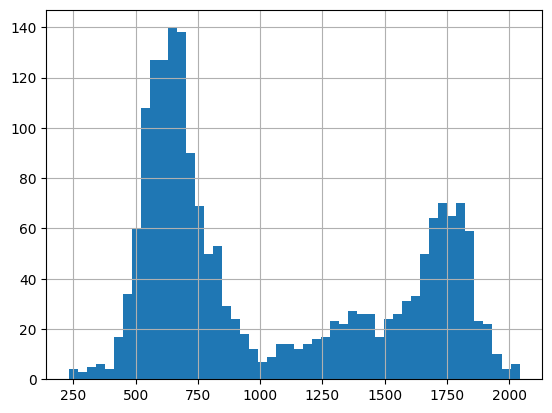

In [ ]:
#시각화
import matplotlib.pyplot as plt
df["text_length"].hist(bins=50) #텍스트 길이 분포

<Axes: >

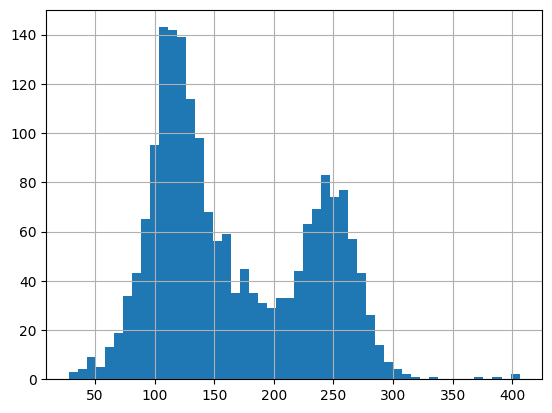

In [ ]:
df["token_length"].hist(bins=50)

In [ ]:
final_df = df[["text", "label"]].copy()

## KLUE RoBERTa Fine Tuning

### 라이브러리

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import Dataset
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# GPU 상태 전체 확인
import torch
print("=== GPU 상태 확인 ===")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
print(f"CUDA 버전: {torch.version.cuda}")
print(f"PyTorch 버전: {torch.__version__}")

if torch.cuda.is_available():
    print(f"GPU 개수: {torch.cuda.device_count()}")
    print(f"현재 GPU: {torch.cuda.current_device()}")
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("❌ GPU를 인식하지 못했습니다!")

# 시스템 정보 확인
!nvidia-smi

=== GPU 상태 확인 ===
CUDA 사용 가능: True
CUDA 버전: 12.4
PyTorch 버전: 2.6.0+cu124
GPU 개수: 1
현재 GPU: 0
GPU 이름: Tesla T4
Sun Jun 15 10:32:26 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                             

In [ ]:
import torch
print(torch.cuda.is_available())
!nvidia-smi

True
Sun Jun 15 10:32:26 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             13W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+

### 모델 및 토크나이저
+ special tokenizer?
  - transformer 기반 모델은 일반적으로 [CLS], [SEP], [pad] 등과 같은 특별한 의미를 가진 토큰을 사용하는데, 이 외에도 원하는 커스텀 토큰을 등록할 수 있다.
  - <SPEAKER_A> : A가 말하는 문장 시작
  - <SPEAKER_B> : B가 말하는 문장 시작

In [ ]:
#model
model_name = "klue/roberta-base" #파라미터 110M개
#load tokenizer + add special token
tokenizer = AutoTokenizer.from_pretrained(model_name)
special_tokens_dict = {
    'additional_special_tokens': ['<SPEAKER_A>', '<SPEAKER_B>']
}
num_added_tokens = tokenizer.add_special_tokens(special_tokens_dict)
print(f"{num_added_tokens} special tokens added.")
#load model + 토큰 수에 맞게 임베딩 조정
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)  # 이진 분류
model.resize_token_embeddings(len(tokenizer))

print('klue RoBERTa 모델 로딩 완료!')
print(f'모델 파라미터 수 : {model.num_parameters():,}')
#special token 확인
print(tokenizer.special_tokens_map)
print(tokenizer.additional_special_tokens)

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/752k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

2 special tokens added.


config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


klue RoBERTa 모델 로딩 완료!
모델 파라미터 수 : 110,621,186
{'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]', 'additional_special_tokens': ['<SPEAKER_A>', '<SPEAKER_B>']}
['<SPEAKER_A>', '<SPEAKER_B>']


### train test split

In [ ]:
# 원본 대화 단위 split
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    final_df,
    test_size=0.2,
    stratify=final_df['label'],
    shuffle=True,
    random_state=42
)

print(f"Train 대화 수: {len(train_df)}, Val 대화 수: {len(val_df)}")

Train 대화 수: 1535, Val 대화 수: 384


In [ ]:
train_df.head()

,text,label
79,"<SPEAKER_A>안녕, 자기야! 잘 지냈어? 주말 어땠어? <SPEAKER_B>...",1
1778,<SPEAKER_A>나 7시에 일어나서 준비하고 다녀오려고 <SPEAKER_B>오오...,0
97,"<SPEAKER_A>야, 안녕! <SPEAKER_A>어, 안녕! <SPEAKER_A...",1
1796,<SPEAKER_A>오빠야 어머니는 어떤 분이셔? <SPEAKER_B>우리 어머니는...,0
1054,<SPEAKER_A>지금 TV에서 코난 하는데 보고 있어? 키키 <SPEAKER_B...,0


### sliding window method
- 목적
  - 최대 토큰을 초과할 경우 슬라이딩 윈도우로 나눠서 정보를 보존한다

- window size : 512 , stride : 384
- 최대 512 토큰을 넘어가면 128토큰이 겹치게 적용
  - 즉, 512 토큰씩 잘려 나가고, 다음 chunk 는 384번째 토큰 후부터 시작된다
  - 하나의 대화로부터 여러 개의 샘플이 생성된다.
- 적용 결과
  - train : 1535 -> 1917
  - val : 384 -> 476

In [ ]:
# Token sliding 적용
from torch.nn.functional import pad

def create_token_sliding_inputs_for_training(texts, labels, tokenizer, window_size=512, stride=384):
    input_ids_list = []
    attention_mask_list = []
    target_labels = []

    pad_token_id = tokenizer.pad_token_id

    for text, label in zip(texts, labels):
        inputs = tokenizer(text, truncation=False, max_length=10000, return_tensors='pt')
        input_ids = inputs['input_ids'][0]
        attention_mask = inputs['attention_mask'][0]

        seq_len = len(input_ids)

        for i in range(0, seq_len, stride):
            input_ids_chunk = input_ids[i:i + window_size]
            attention_mask_chunk = attention_mask[i:i + window_size]

            # 패딩 추가
            pad_len = window_size - input_ids_chunk.size(0)
            if pad_len > 0:
                input_ids_chunk = pad(input_ids_chunk, (0, pad_len), value=pad_token_id)
                attention_mask_chunk = pad(attention_mask_chunk, (0, pad_len), value=0)

            input_ids_list.append(input_ids_chunk)
            attention_mask_list.append(attention_mask_chunk)
            target_labels.append(label)

            if i + window_size >= seq_len:
                break

    return input_ids_list, attention_mask_list, target_labels



# Sliding 적용
train_input_ids, train_attention_masks, train_target_labels = create_token_sliding_inputs_for_training(
    train_df['text'],
    train_df['label'],
    tokenizer,
    window_size=512,
    stride=512
)

val_input_ids, val_attention_masks, val_target_labels = create_token_sliding_inputs_for_training(
    val_df['text'],
    val_df['label'],
    tokenizer,
    window_size=512,
    stride=512
)

print(f"Train window 수: {len(train_input_ids)}, Val window 수: {len(val_input_ids)}")

Train window 수: 1917, Val window 수: 476


In [ ]:
#hugging face의 trainer API 활용을 위해 슬라이딩 윈도우 객체들을 dataset 객체로 변환
from datasets import Dataset

train_dataset = Dataset.from_dict({
    'input_ids': [x.tolist() for x in train_input_ids],
    'attention_mask': [x.tolist() for x in train_attention_masks],
    'label': train_target_labels
})

val_dataset = Dataset.from_dict({
    'input_ids': [x.tolist() for x in val_input_ids],
    'attention_mask': [x.tolist() for x in val_attention_masks],
    'label': val_target_labels
})

### 평가지표 설정

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.special import softmax

def compute_metrics(eval_pred):
    print("🔍 compute_metrics called")  #디버깅 목적
    logits, labels = eval_pred  #trainer가 넘겨주는 (logits, labels) 튜플을 받음

    # 소프트맥스를 적용해서 확률값 추출
    probs = softmax(logits, axis=1) #logits에 소프트맥스 적용해 원시값을 확률 벡터로 변환
    preds = np.argmax(probs, axis=-1)
    #이진분류 지표
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='binary')
    recall = recall_score(labels, preds, average='binary')
    f1 = f1_score(labels, preds, average='binary')

    # 클래스 1에 대한 확률값으로 AUC 계산
    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except:
        auc = float('nan')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }


In [ ]:
import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU available")

Tesla T4


In [ ]:
#모델을 GPU로 옮기는 코드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #TRUE면 GPU 사용 , 아니면 CPU 사용
model.to(device) #모델의 파라미터, 버퍼를 device(gpu)로 옮기는 것
next(model.parameters()).device

#결과 - cuda : Colab의 할당된 NVIDIA GPU 의미

device(type='cuda', index=0)

### 훈련 인자 설정

In [ ]:
#wandb 초기화 확인
import wandb
wandb.init(project="Online_Grooming_detection", name="klue-roberta-run1")
print(wandb.login())  # True 출력 확인

#학습 설정 (훈련인자)
from transformers import TrainingArguments

# 실험 결과를 날짜별로 저장
from datetime import datetime
current_time = datetime.now().strftime("%Y%m%d_%H%M%S")

training_args = TrainingArguments(
    output_dir=f"./results/roberta_{current_time}",      # 모델 저장 경로(모델 체크포인트 저장 위치)
    num_train_epochs=3,                        # 학습 반복 횟수
    per_device_train_batch_size=8,             # 배치 크기
    per_device_eval_batch_size=16,             # 평가할 때는 좀 더 큰 배치 사용 가능
    learning_rate=2e-5,                        # 학습률 (사전훈련 모델에는 작은 값)
    weight_decay=0.01,                         # 과적합 방지를 위해 weight decay
    warmup_ratio=0.1,                          # 처음 10%는 학습률을 천천히 올림

    # 평가/저장
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,              # 50스텝마다 로깅

    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,

    report_to="wandb",
    run_name="klue-roberta-run_stride512",
    save_total_limit=2
)

eval/accuracy,▁▁▁
eval/auc,▁▁▁
eval/f1,▁▁▁
eval/loss,█▁▁
eval/precision,▁▁▁
eval/recall,▁▁▁
eval/runtime,▁█▆
eval/samples_per_second,█▁▃
eval/steps_per_second,█▁▃
train/epoch,▁▂▂▃▃▃▄▄▅▅▅▆▆▇▇███
train/global_step,▁▂▂▃▃▃▄▄▅▅▅▆▆▇▇███


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True


### trainer 객체 생성

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # 자동 분할 없이 직접 넣은 테스트셋
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print(f"Trainer compute_metrics attribute: {trainer.compute_metrics}")
print(f"Test dataset columns: {val_dataset.column_names}")

Trainer compute_metrics attribute: <function compute_metrics at 0x7a0a3a0d11c0>
Test dataset columns: ['input_ids', 'attention_mask', 'label']


### training

In [ ]:
#학습 시작
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.000100,0.000061,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.000000,0.000032,1.000000,1.000000,1.000000,1.000000,1.000000


🔍 compute_metrics called
🔍 compute_metrics called


KeyboardInterrupt: 

### model evaluation

In [ ]:
#학습 후 평가
trainer.evaluate()

In [ ]:
# 학습 끝난 후 별도로 평가
trainer.evaluate(val_dataset)

### save model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

save_dir = ""
model = AutoModelForSequenceClassification.from_pretrained(save_dir)
tokenizer = AutoTokenizer.from_pretrained(save_dir)